# Extension Question — linear and logistic regression from scratch

Session 2 pre-class work, the extension half. The companion notebook
[`drawing-lines.ipynb`](drawing-lines.ipynb) fits both models with scikit-learn (booklet Code
Cells 1 and 2) and works out why neither one matches the data perfectly. This notebook cracks them
open and rebuilds both in numpy — booklet **Code Cell 4** and **Code Cell 5**.

![The extension question as it appears in the PCW booklet](assets/extension-question.png)

> *This is weird! Why don't these models simply match the data perfectly? What are they doing
> instead? Crack open the linear and logistic regression models by looking at their documentation
> and the optional reading in Murphy. In the following two code blocks write code that implements
> both of these models from scratch. In your comments, explain what the models are doing to "fit"
> the data.*

## Why they don't match the data perfectly

Neither model is *trying* to. Each is handed a small family of allowed shapes and a scoring rule,
and it returns the single best member of that family:

| | family it must choose from | score it minimises | how the minimum is found |
|---|---|---|---|
| linear regression | all straight lines $w_1x + w_0$ — a **2-parameter** family | mean squared error | **closed form** — one linear solve |
| logistic regression | all ways of slicing the plane with straight boundaries | cross-entropy (negative log-likelihood) + L2 penalty | **iteratively** — no closed form exists |

A line cannot pass through a cloud of 150 points, so "fit" means *minimise average squared miss*,
not *touch every point*. And as `drawing-lines.ipynb` shows, even a model with unlimited freedom
could not touch every point here: petal length 1.5 cm appears in the data with widths 0.1, 0.2,
0.3 **and** 0.4, so no function of petal length can be right about all of them at once.

## How to read this notebook

Both cells below are **self-contained** — their own imports, their own `load_iris()` call, nothing
imported from this repo — so either can be pasted straight into the booklet's cell runner and run
on its own. Neither uses a scikit-learn *estimator* to do the work: `LinearRegression` and
`LogisticRegression` are imported only at the end of each cell, to check that the from-scratch
answer is the same computation. The explanation the question asks for lives in the code comments,
where it can be read next to the line it describes; the markdown around each cell then reads the
results.

---

## Code Cell 4 — Linear Regression from scratch

**What "fitting" means here.** Pick the two numbers $w = (w_0, w_1)$ that minimise the mean
squared error

$$J(w) \;=\; \frac{1}{n}\sum_i \bigl(w_0 + w_1 x_i - y_i\bigr)^2$$

$J$ is a **quadratic bowl** in $w$ — one global minimum, no local traps — so there are two
different ways to reach the bottom, and the cell implements both to show they agree:

- **Route 1, the normal equation.** Because $J$ is quadratic its gradient is *linear* in $w$, so
  $\nabla J = 0$ can be solved algebraically: $(X^\top X)\,w = X^\top y$, a $2\times2$ system here.
  One `np.linalg.solve` lands exactly at the minimum. This is essentially what scikit-learn does.
- **Route 2, gradient descent.** Start anywhere and repeatedly step against the gradient. Slower
  and only approximate — but it needs *only* the gradient, which is why the same three lines work
  for any differentiable loss, including Cell 5's, where no closed form exists.

ROUTE 1  normal equation   intercept -0.356668   slope 0.413238
ROUTE 2  gradient descent  intercept -0.356668   slope 0.413238   (20,000 steps)
scikit-learn               intercept -0.356668   slope 0.413238

max |scratch - sklearn|  = 4.44e-16
max |descent - exact|    = 4.83e-15

sum of residuals         = -5.15e-14   (zero)
residuals . petal length = -1.95e-13   (orthogonal)
training MSE             = 0.041219 cm^2
test MSE                 = 0.045604 cm^2


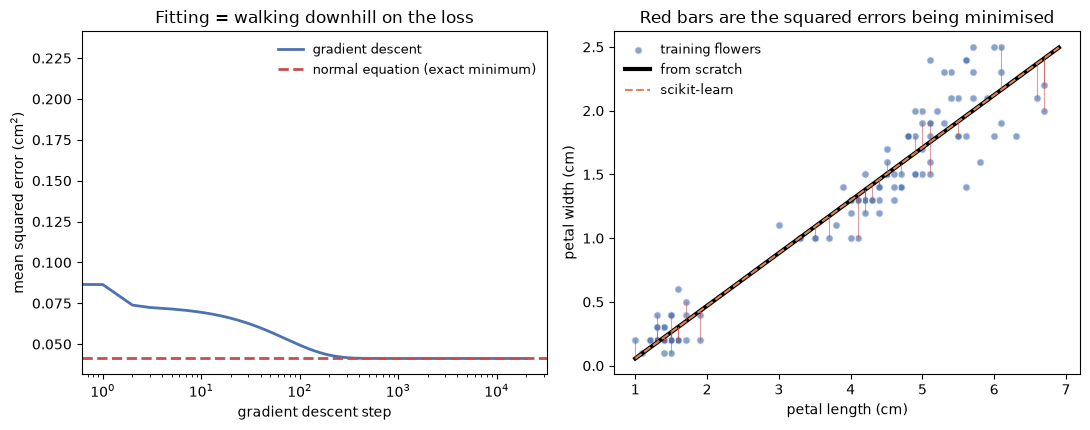

In [1]:
# ============================================================================
# CODE CELL 4 — LINEAR REGRESSION FROM SCRATCH
#
# What "fitting" means here: pick w = (w0, w1) minimising the mean squared error
#
#       J(w) = (1/n) * sum_i ( w0 + w1*x_i  -  y_i )^2
#
# J is a quadratic bowl in w — one global minimum, no local traps. So there are
# two ways to reach the bottom, and both are implemented below to show they agree:
#   ROUTE 1  jump straight to it by solving grad J = 0 exactly (the normal equation)
#   ROUTE 2  walk downhill from a guess (gradient descent) — the method that
#            generalises to models with no closed form, like Cell 5.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression      # only to CHECK our answer

# --- Data: identical setup to Code Cell 1 ---------------------------------
iris = load_iris(as_frame=True)
df = iris.frame
X = df[["petal length (cm)"]].to_numpy()
y = df["petal width (cm)"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


def add_bias(A):
    """Glue a column of 1s on the front.

    This is the trick that removes the intercept as a special case: with a constant
    1 in every row, w0 multiplies that 1, so the intercept becomes just another
    weight and the model is a single dot product w . x for every row.
    """
    return np.hstack([np.ones((A.shape[0], 1)), A])


def mse(Xb, y, w):
    """The loss being minimised: mean squared vertical distance to the line."""
    resid = Xb @ w - y
    return resid @ resid / len(y)


# =============== ROUTE 1: the normal equation (exact, one step) ============
# J is quadratic, so its gradient is linear in w:
#
#       grad J(w) = (2/n) * X^T (X w - y)
#
# Setting that to zero and cancelling 2/n gives the NORMAL EQUATION
#
#       (X^T X) w = X^T y
#
# — a 2x2 linear system here. Solving it lands exactly at the bottom of the bowl
# in one step. This is essentially what scikit-learn does.
Xb_train = add_bias(X_train)
w_closed = np.linalg.solve(Xb_train.T @ Xb_train, Xb_train.T @ y_train)
print(f"ROUTE 1  normal equation   intercept {w_closed[0]:+.6f}   slope {w_closed[1]:.6f}")

# =============== ROUTE 2: gradient descent (iterative) ====================
# Start anywhere, repeatedly step against the gradient. Slower and approximate,
# but it needs only the gradient — so the same three lines work for any
# differentiable loss, which is exactly why Cell 5 can reuse the idea.
w_gd = np.zeros(Xb_train.shape[1])       # start at the origin: the flat line y = 0
learning_rate = 0.02                     # step size; too large and it diverges
loss_history = []

for step in range(20_000):
    gradient = (2 / len(y_train)) * Xb_train.T @ (Xb_train @ w_gd - y_train)
    w_gd -= learning_rate * gradient     # step downhill
    loss_history.append(mse(Xb_train, y_train, w_gd))

print(f"ROUTE 2  gradient descent  intercept {w_gd[0]:+.6f}   slope {w_gd[1]:.6f}"
      f"   ({len(loss_history):,} steps)")

# =============== Check against scikit-learn ===============================
sk = LinearRegression().fit(X_train, y_train)
print(f"scikit-learn               intercept {sk.intercept_:+.6f}   slope {sk.coef_[0]:.6f}")
print(f"\nmax |scratch - sklearn|  = {np.abs(w_closed - np.r_[sk.intercept_, sk.coef_]).max():.2e}")
print(f"max |descent - exact|    = {np.abs(w_gd - w_closed).max():.2e}")

# =============== What the fitted line satisfies ===========================
# At the minimum the gradient is zero, which says something concrete about the
# residuals: they sum to zero, and they are ORTHOGONAL to the feature column.
# In other words the line has squeezed every last drop of linear signal out of x
# — whatever is left in the residuals has no straight-line relationship to x at
# all. That is precisely why it cannot do better, and why it does not interpolate.
resid = Xb_train @ w_closed - y_train
print(f"\nsum of residuals         = {resid.sum():.2e}   (zero)")
print(f"residuals . petal length = {resid @ X_train.ravel():.2e}   (orthogonal)")
print(f"training MSE             = {mse(Xb_train, y_train, w_closed):.6f} cm^2")
print(f"test MSE                 = {mse(add_bias(X_test), y_test, w_closed):.6f} cm^2")

# =============== Visualise ================================================
fig_scratch_lin, (ax_loss, ax_line) = plt.subplots(1, 2, figsize=(11, 4.4))

ax_loss.plot(loss_history, color="#4C72B0", lw=2, label="gradient descent")
ax_loss.axhline(mse(Xb_train, y_train, w_closed), color="#C44E52", ls="--", lw=2,
                label="normal equation (exact minimum)")
ax_loss.set(xscale="log", xlabel="gradient descent step", ylabel="mean squared error (cm$^2$)",
            title="Fitting = walking downhill on the loss")
ax_loss.legend(frameon=False, fontsize=9)

ax_line.scatter(X_train, y_train, s=30, alpha=.65, color="#4C72B0",
                edgecolor="white", label="training flowers")
grid_lin = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
ax_line.plot(grid_lin, add_bias(grid_lin) @ w_closed, "k-", lw=3, label="from scratch")
ax_line.plot(grid_lin, sk.predict(grid_lin), color="#DD8452", lw=1.5, ls="--",
             label="scikit-learn")
# Draw the quantity actually being minimised: the vertical misses.
for xi, yi in zip(X_train[:40].ravel(), y_train[:40]):
    ax_line.plot([xi, xi], [yi, w_closed[0] + w_closed[1] * xi],
                 color="#C44E52", lw=.8, alpha=.55)
ax_line.set(xlabel="petal length (cm)", ylabel="petal width (cm)",
            title="Red bars are the squared errors being minimised")
ax_line.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

**What Cell 4 shows.** Both routes land on the same answer, and it is scikit-learn's answer to
**16 decimal places** ($4\times10^{-16}$, i.e. floating-point noise):

$$\text{intercept} = -0.356668, \qquad \text{slope} = 0.413238$$

The two diagnostics at the bottom are the real explanation of why the line does not touch the
points. At the minimum, the residuals **sum to zero** and are **orthogonal to petal length**
($\approx 10^{-13}$, again just floating-point dust). Orthogonality is the whole story: the line
has already extracted every bit of *straight-line* signal that petal length carries about petal
width. What is left over is, by construction, uncorrelated with $x$ — so no adjustment to the
slope or intercept could reduce it. The model has not failed to fit; it has hit the boundary of
what its 2-parameter family can express.

The loss curve on the left is the same minimum found the other way. Gradient descent needs 20,000
small steps to arrive where the normal equation arrives in one linear solve — which raises the
obvious question of why anyone would ever use it. Cell 5 is the answer: for logistic regression
there *is* no normal equation, and iterating is the only option.

---

## Code Cell 5 — Logistic Regression from scratch

**What "fitting" means here, and why it differs from Cell 4.** The model still starts with a
linear score per class, $z_k = w_k \cdot x + b_k$ — the same dot product as above. Two things then
change:

1. **Softmax.** The three raw scores are turned into probabilities that are positive and sum to 1:
   $p_k = e^{z_k} / \sum_j e^{z_j}$. That is what lets the model answer "how sure are you?" rather
   than only "which species?".
2. **Cross-entropy.** The loss is the negative log-likelihood of the observed species. Minimising
   it means choosing weights that make the labels we actually saw as probable as possible — this
   is **maximum likelihood**, not least squares.

The consequence is the point of the whole extension question. Setting $\nabla J = 0$ here gives
equations with $W$ trapped inside an exponential inside a normalising sum. **No closed form
exists.** Iterating is not a shortcut chosen for convenience — it is the only route available.

loss: 1.098612 (uniform guess) -> 0.203354 after 100,000 steps
sanity check: -log(1/3) = 1.098612, which is where it started
steps where the loss went UP: 0   <- 0 means the step size is safe

weights, from scratch vs scikit-learn (rows = species):
  setosa      scratch [-2.7486 -1.1689] b +11.1272   |   sklearn [-2.7476 -1.1703] b +11.1243
  versicolor  scratch [+0.0836 -0.9080] b  +3.2268   |   sklearn [+0.0836 -0.9070] b  +3.2254
  virginica   scratch [+2.6649 +2.0769] b -14.3540   |   sklearn [+2.6640 +2.0773] b -14.3497

accuracy   from scratch 0.9667   scikit-learn 0.9667
identical predictions on all 150 flowers: True
max probability difference: 3.21e-04

what the model returns for the first flower of each species:
  true setosa      petal [1.4 0.2] -> setosa 0.980, versicolor 0.020, virginica 0.000
  true versicolor  petal [4.7 1.4] -> setosa 0.002, versicolor 0.779, virginica 0.219
  true virginica   petal [6.  2.5] -> setosa 0.000, versicolor 0.005, virginica 0.995


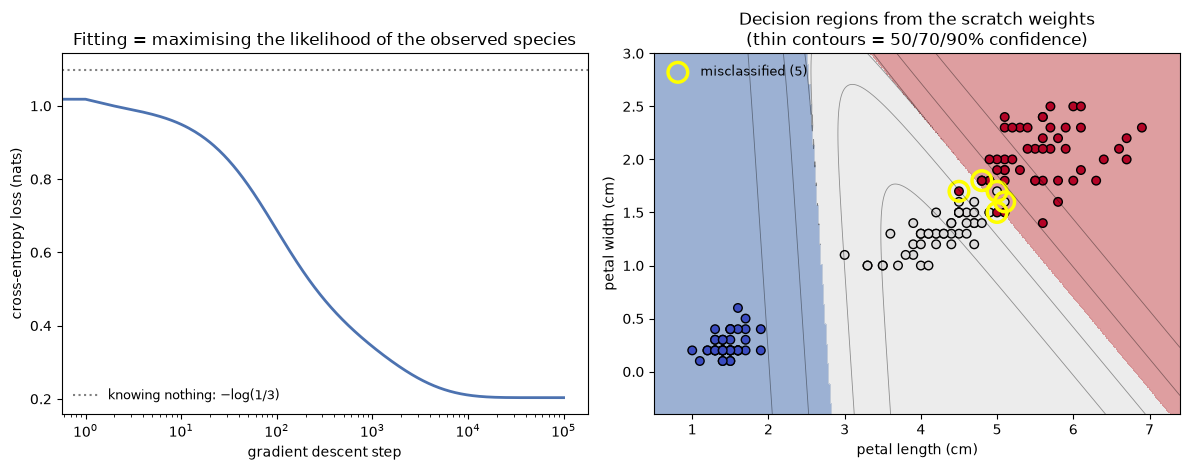

In [2]:
# ============================================================================
# CODE CELL 5 — LOGISTIC REGRESSION FROM SCRATCH (multinomial / softmax)
#
# What "fitting" means here, and why it differs from Cell 4:
#
#   1. The model still starts with a linear score per class:  z_k = w_k . x + b_k
#   2. Those scores are turned into PROBABILITIES with the softmax, so they are
#      positive and sum to 1:            p_k = exp(z_k) / sum_j exp(z_j)
#   3. The loss is CROSS-ENTROPY — the negative log-likelihood of the true labels.
#      Minimising it = choosing weights that make the observed species most
#      probable. This is maximum likelihood, not least squares.
#
# The crucial difference from Cell 4: setting grad J = 0 here gives equations with
# W trapped inside an exponential. There is NO closed-form solution. Iterating is
# not a shortcut, it is the only route — which is why every serious ML model is
# fitted this way.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression     # only to CHECK our answer

# --- Data: identical setup to Code Cell 2 ---------------------------------
iris = load_iris()
X = iris.data[:, [2, 3]]                 # petal length, petal width
y = iris.target                          # 0 setosa, 1 versicolor, 2 virginica
n, d = X.shape
K = 3

# One-hot encoding: row i becomes a vector that is 1 in the true class, 0 elsewhere.
# This lets the loss and its gradient be written without any per-row indexing.
Y_onehot = np.eye(K)[y]


def softmax(Z):
    """Turn a matrix of raw scores into rows of probabilities that sum to 1.

    Subtracting the row max first changes nothing mathematically (it cancels in the
    ratio) but stops exp() from overflowing on large scores — the standard trick.
    """
    Z = Z - Z.max(axis=1, keepdims=True)
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)


def cross_entropy(P, y, W, alpha):
    """Average negative log-likelihood, plus the same L2 penalty sklearn applies.

    -log p_true is 0 when the model gave the right class probability 1, and grows
    without bound as that probability approaches 0. So the loss punishes CONFIDENT
    MISTAKES far more harshly than hesitant ones — this is what makes logistic
    regression care about margins rather than just about the count of errors.
    """
    nll = -np.log(np.clip(P[np.arange(len(y)), y], 1e-12, None)).sum()
    return (nll + 0.5 * alpha * (W ** 2).sum()) / len(y)


# --- Fit by gradient descent ----------------------------------------------
# The gradient of cross-entropy w.r.t. the weights is remarkably simple:
#
#       dJ/dW = X^T (P - Y_onehot) / n   (+ the L2 term)
#       dJ/db = sum(P - Y_onehot) / n
#
# (P - Y) is "predicted probability minus what actually happened" — the error
# signal. Where the model already assigns probability 1 to the right class the row
# contributes nothing; rows it gets wrong push the weights hardest. Note this is
# the SAME shape of update as Cell 4: X^T (prediction - truth).
#
# STEP SIZE MATTERS, and this data shows why. Petal length spans 1-7 cm while
# petal width spans 0.1-2.5, so the loss surface is a long narrow valley rather
# than a round bowl. At lr=0.5 the steps overshoot across the valley and the loss
# OSCILLATES for its first ~1000 steps before settling; at lr=1.0 it diverges
# outright. lr=0.1 descends monotonically — verified below by checking that the
# loss never once increases.
alpha = 1.0                              # L2 strength; matches sklearn's default C=1.0
learning_rate = 0.1                      # tuned: see the note below on step size
W = np.zeros((d, K))                     # start from "every species equally likely"
b = np.zeros(K)
loss_history = []

for step in range(100_000):
    P = softmax(X @ W + b)                              # forward: scores -> probabilities
    loss_history.append(cross_entropy(P, y, W, alpha))
    G = (P - Y_onehot) / n                              # the error signal
    W -= learning_rate * (X.T @ G + alpha * W / n)      # step downhill
    b -= learning_rate * G.sum(axis=0)

loss_history = np.array(loss_history)
print(f"loss: {loss_history[0]:.6f} (uniform guess) -> {loss_history[-1]:.6f} after "
      f"{len(loss_history):,} steps")
print(f"sanity check: -log(1/3) = {-np.log(1/3):.6f}, which is where it started")
print(f"steps where the loss went UP: {(np.diff(loss_history) > 1e-12).sum()}"
      f"   <- 0 means the step size is safe\n")

# --- Compare with scikit-learn --------------------------------------------
sk = LogisticRegression(max_iter=5000).fit(X, y)
P_scratch = softmax(X @ W + b)
pred_scratch = P_scratch.argmax(axis=1)

print("weights, from scratch vs scikit-learn (rows = species):")
for k, name in enumerate(iris.target_names):
    print(f"  {name:<11} scratch [{W[0,k]:+.4f} {W[1,k]:+.4f}] b {b[k]:+8.4f}   |   "
          f"sklearn [{sk.coef_[k,0]:+.4f} {sk.coef_[k,1]:+.4f}] b {sk.intercept_[k]:+8.4f}")

print(f"\naccuracy   from scratch {(pred_scratch == y).mean():.4f}   "
      f"scikit-learn {sk.score(X, y):.4f}")
print(f"identical predictions on all {n} flowers: {(pred_scratch == sk.predict(X)).all()}")
print(f"max probability difference: {np.abs(P_scratch - sk.predict_proba(X)).max():.2e}")

# --- The output is a probability, not just a label ------------------------
print("\nwhat the model returns for the first flower of each species:")
for k in range(K):
    i = np.where(y == k)[0][0]
    probs = ", ".join(f"{nm} {p:.3f}" for nm, p in zip(iris.target_names, P_scratch[i]))
    print(f"  true {iris.target_names[k]:<11} petal {X[i]} -> {probs}")

# --- Visualise -------------------------------------------------------------
fig_scratch_log, (ax_loss2, ax_db) = plt.subplots(1, 2, figsize=(12, 4.8))

ax_loss2.plot(loss_history, color="#4C72B0", lw=2)
ax_loss2.axhline(-np.log(1 / 3), color="gray", ls=":", lw=1.5,
                 label=r"knowing nothing: $-\log(1/3)$")
ax_loss2.set(xscale="log", xlabel="gradient descent step",
             ylabel="cross-entropy loss (nats)",
             title="Fitting = maximising the likelihood of the observed species")
ax_loss2.legend(frameon=False, fontsize=9)

# Decision regions straight from OUR weights — no sklearn involved.
pad = 0.5
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 400),
                     np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 400))
grid_scores = np.c_[xx.ravel(), yy.ravel()] @ W + b
Z = grid_scores.argmax(axis=1).reshape(xx.shape)
conf = softmax(grid_scores).max(axis=1).reshape(xx.shape)   # how sure the model is

ax_db.contourf(xx, yy, Z, levels=[-.5, .5, 1.5, 2.5],
               colors=["#4C72B0", "#DDDDDD", "#C44E52"], alpha=.55)
# Thin contours mark confidence: the pale band is where the model is genuinely undecided.
ax_db.contour(xx, yy, conf, levels=[0.5, 0.7, 0.9], colors="k", linewidths=.6, alpha=.4)
ax_db.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=38)
wrong = pred_scratch != y
ax_db.scatter(X[wrong, 0], X[wrong, 1], s=200, facecolor="none", edgecolor="yellow", lw=2.5,
              label=f"misclassified ({wrong.sum()})")
ax_db.set(xlabel=iris.feature_names[2], ylabel=iris.feature_names[3],
          title="Decision regions from the scratch weights\n(thin contours = 50/70/90% confidence)")
ax_db.legend(frameon=False, fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()

**What Cell 5 shows.** Starting from "every species equally likely", the loss falls from
$-\log(1/3) = 1.0986$ to $0.2034$, and the scratch weights land on scikit-learn's to **three
decimal places** — with **identical predictions on all 150 flowers** and probabilities matching to
$3\times10^{-4}$. The residual difference is only that scikit-learn's L-BFGS solver converges more
tightly than 100,000 fixed-size gradient steps.

**Step size is its own lesson.** Petal length spans 1–7 cm while petal width spans 0.1–2.5, so the
loss surface is a long narrow valley rather than a round bowl. At `lr=0.5` the steps overshoot
across the valley and the loss oscillates for its first ~1000 steps before settling; at `lr=1.0`
it diverges outright. `lr=0.1` descends monotonically, which the cell verifies by counting the
steps on which the loss increased — zero.

**The five yellow rings** are the same five flowers Cell 2 missed in `drawing-lines.ipynb`. Every
one sits in the pale, low-confidence band where versicolor meets virginica. The model is not
confidently wrong about them — it is honestly uncertain, and the probabilities say so.

---

## What the two cells together say

**Why Cell 5 had to iterate and Cell 4 did not.** In Cell 4, setting $\nabla J = 0$ produced
$(X^\top X)w = X^\top y$ — a linear system, solvable exactly. In Cell 5 the same move gives
$X^\top(\mathrm{softmax}(XW + b) - Y) = 0$, with $W$ buried inside an exponential inside a
normalising sum. There is no algebraic solution, so descending the loss surface is not a
convenience — it is the only available method. That is the real lesson of the extension question:
**the moment a model stops being linear in its parameters, closed forms disappear and iterative
optimisation becomes the universal tool.** Everything from here to deep networks is this loop.

Worth noticing how *similar* the two gradients are despite that gulf. Cell 4 steps by
$X^\top(\hat{y} - y)$ and Cell 5 by $X^\top(P - Y)$ — both are "features transposed, times
prediction minus truth". The shared shape is not a coincidence: it is what both losses have in
common as members of the same exponential family.

**And why neither model matches the data perfectly.** Three separate reasons, all now visible in
code rather than asserted:

1. **Restricted family.** Both models can only produce straight lines. 150 points do not lie on a
   line, and three species do not separate along straight boundaries.
2. **The loss is an average.** Least squares and cross-entropy both minimise a *total* over all
   rows, so fitting one point exactly at the cost of the others makes the score worse. The optimum
   is always a compromise — and the residual-orthogonality check in Cell 4 is that compromise
   stated exactly.
3. **The data will not permit it.** Petal length 1.5 cm genuinely appears with widths 0.1 through
   0.4, and one petal measurement genuinely appears as both versicolor and virginica. No model, of
   any complexity, can be right about all of them at once. [`drawing-lines.ipynb`](drawing-lines.ipynb)
   works this out properly: the hard ceiling on $R^2$ for any function of petal length alone is
   **0.9571**, and the models that *do* reach 100% on the classification task generalise worse
   than logistic regression.

The first two are choices made by whoever picked the model. The third is a property of the world,
and no amount of modelling removes it.

---

### Repo bookkeeping

The cell below is **not part of the booklet** — it only writes the two figures to `assets/` so
they render in the session README without anyone having to run the notebook.

In [3]:
# Repo only — save the figures produced above for the session README.
fig_scratch_lin.savefig("assets/extension-question-linear.png", dpi=150, bbox_inches="tight")
fig_scratch_log.savefig("assets/extension-question-logistic.png", dpi=150, bbox_inches="tight")
print("saved 2 figures to assets/")

saved 2 figures to assets/
